# Handling Missing Data : Simple Imputer (Numerical)

- the missing data can be handled by two ways either removing those missing rows or impute them.
- for numerical data , we can apply simple imputer in two ways :
  1. Univariate
  2. Bivariate

- In Univariate simple imputation , we will randomly fill with columns mean/median or any values, from the column values itself or any statistical techniques.
- In Multivariate simple imputation , we will use multiple columns for imputing the cell values.


## Techniques Used for handling Missing Data

1. Mean/Median Imputation
2. Arbitrary Value Imputation
3. End of Imputation
4. Random Sample Imputation

# #1 Mean/Median Imputation

1. *When to use*: when missing data is MCAR (Missing Completely At Random) or Missing less than 5%.
2. *Benfits*:

   - i. Simple
   - ii. can be used upto 5% missing data.
     
3. *Disadvantages*

    - i.Affects the distribution shape.
    - ii. can produce Outliers.
    - iii. Covariant or correlation change

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df=df.drop(columns=['PassengerId','Pclass','Name','Sex','Ticket','Cabin','Embarked'])
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [8]:
df=df.drop(columns=['PassengerId','Pclass','Name','Sex','Ticket','Cabin','Embarked'])
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [9]:
df['Family']=df['SibSp']+df['Parch']
df.head()

,Survived,Age,SibSp,Parch,Fare,Family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [10]:
df=df.drop(columns=['SibSp','Parch'])
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [11]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
Family      0.000000
dtype: float64

In [12]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [14]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [15]:
x_train.isnull().mean()

Age       0.207865
Fare      0.000000
Family    0.000000
dtype: float64

In [17]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

In [19]:
print(f'Mean Age :{mean_age}\nMedian Age: {median_age}')

Mean Age :29.78590425531915
Median Age: 28.75


In [18]:
x_train['Age_Median']=x_train['Age'].fillna(median_age)
x_train['Age_Mean']=x_train['Age'].fillna(mean_age)

In [20]:
x_train.sample(5)

,Age,Fare,Family,Age_Median,Age_Mean
308,30.0,24.0000,1,30.0,30.0
632,32.0,30.5000,0,32.0,32.0
622,20.0,15.7417,2,20.0,20.0
467,56.0,26.5500,0,56.0,56.0
543,32.0,26.0000,1,32.0,32.0


In [22]:
print('Original Age Variable variance:',x_train['Age'].var())
print('Age Variance after median imputation:',x_train['Age_Median'].var())
print('Age Variance after mean imputation:',x_train['Age_Mean'].var())

Original Age Variable variance: 204.3495133904614
Age Variance after median imputation: 161.9895663346054
Age Variance after mean imputation: 161.81262452718673


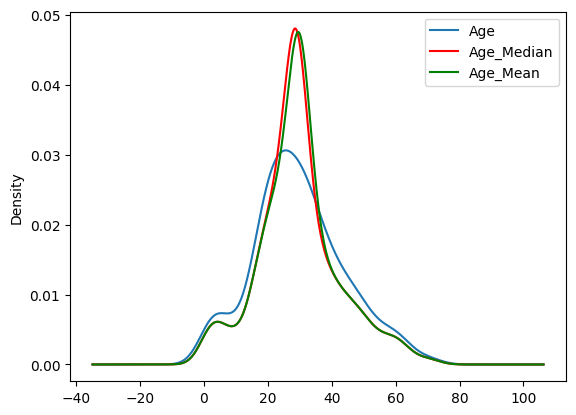

In [25]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the median
x_train['Age_Median'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the mean
x_train['Age_Mean'].plot(kind='kde',ax=ax,color='green')

# add legends
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


In [26]:
x_train.cov()

,Age,Fare,Family,Age_Median,Age_Mean
Age,204.349513,71.512440,-6.498901,204.349513,204.349513
Fare,71.512440,2368.246832,16.847264,58.986531,56.626587
Family,-6.498901,16.847264,2.735252,-5.112563,-5.146106
Age_Median,204.349513,58.986531,-5.112563,161.989566,161.812625
Age_Mean,204.349513,56.626587,-5.146106,161.812625,161.812625


In [27]:
x_train.corr()

,Age,Fare,Family,Age_Median,Age_Mean
Age,1.000000,0.095814,-0.299113,1.000000,1.000000
Fare,0.095814,1.000000,0.209323,0.095235,0.091475
Family,-0.299113,0.209323,1.000000,-0.242883,-0.244610
Age_Median,1.000000,0.095235,-0.242883,1.000000,0.999454
Age_Mean,1.000000,0.091475,-0.244610,0.999454,1.000000


<Axes: >

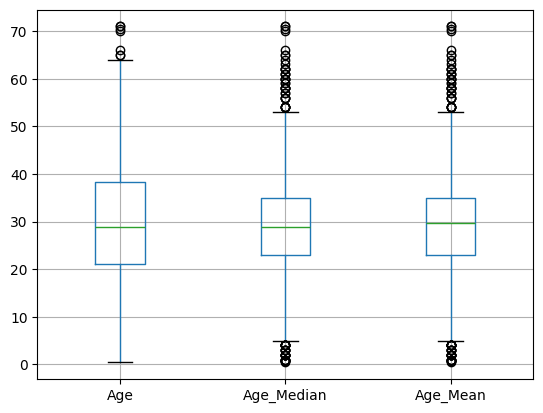

In [28]:
x_train[['Age','Age_Median','Age_Mean']].boxplot()

As we can see ,by imputing with mean and median , the age has increased number of outliers by shrinking the IQR 

# Using Sklearn

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
imputer1=SimpleImputer(strategy='median')
# imputer2=SimpleImputer(strategy='mean')

In [40]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
],remainder='passthrough')

In [41]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age'])])

In [42]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [43]:
x_train=trf.transform(x_train)
y_train=trf.transform(x_test)

In [44]:
x_train


array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.1083,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

# #2. Arbitrary Value Imputation

- Used when data is not missing at random (~MCAR) , instead missing in chunks 
- Impute with any arbitrary value such as 99,-1,9 etc.
- Easy to apply
- *Disadvantages*:
  1. Probability density function changes
  2. variance affected
  3. covariance changes

In [48]:
df=pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
df=df.drop(columns=['PassengerId','Pclass','Name','Sex','Ticket','Cabin','Embarked'])
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [50]:
df['Family']=df['SibSp']+df['Parch']
df.head()

,Survived,Age,SibSp,Parch,Fare,Family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [51]:
df=df.drop(columns=['SibSp','Parch'])
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [52]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
Family      0.000000
dtype: float64

In [53]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [55]:
x_train['Age_99']=x_train['Age'].fillna(99)
x_train['Age_minus']=x_train['Age'].fillna(-1)

In [56]:
print('Original Age variable variance',x_train['Age'].var())
print('Age Variance after 99 wala imputation:',x_train['Age_99'].var())
print('Age Variance after -1 wala imputation:',x_train['Age_minus'].var())

Original Age variable variance 210.2517072477438
Age Variance after 99 wala imputation: 932.9665366701436
Age Variance after -1 wala imputation: 315.99550362600644


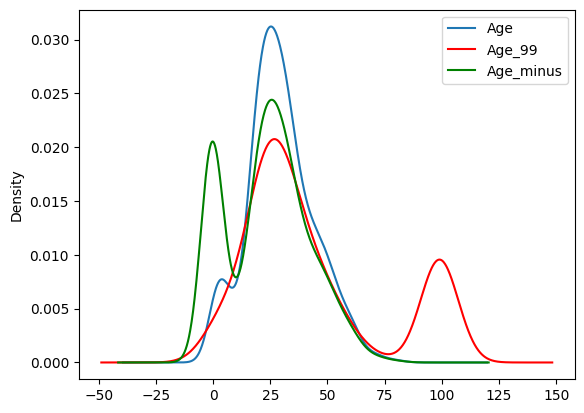

In [57]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the median
x_train['Age_99'].plot(kind='kde',ax=ax,color='red')

# variable imputed with mean 
x_train['Age_minus'].plot(kind='kde',ax=ax,color='green')


# add legends
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

## using sklearn 

In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [60]:
imputer1=SimpleImputer(strategy='constant',fill_value=-1)


In [61]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age'])
])

In [62]:
trf.fit(x_train)

ColumnTransformer(transformers=[('imputer1',
                                 SimpleImputer(fill_value=-1,
                                               strategy='constant'),
                                 ['Age'])])

In [63]:
trf.named_transformers_['imputer1'].statistics_

array([-1.])

In [64]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [65]:
x_train

array([[40.  ],
       [ 4.  ],
       [47.  ],
       [ 9.  ],
       [20.  ],
       [30.  ],
       [30.  ],
       [13.  ],
       [36.  ],
       [-1.  ],
       [31.  ],
       [38.  ],
       [18.  ],
       [-1.  ],
       [25.  ],
       [37.  ],
       [18.  ],
       [35.  ],
       [46.  ],
       [70.5 ],
       [48.  ],
       [48.  ],
       [24.  ],
       [56.  ],
       [54.  ],
       [-1.  ],
       [16.  ],
       [34.  ],
       [-1.  ],
       [43.  ],
       [ 2.  ],
       [50.  ],
       [60.  ],
       [41.  ],
       [ 3.  ],
       [39.  ],
       [33.  ],
       [-1.  ],
       [-1.  ],
       [37.  ],
       [42.  ],
       [19.  ],
       [16.  ],
       [-1.  ],
       [24.  ],
       [45.  ],
       [29.  ],
       [35.  ],
       [-1.  ],
       [30.  ],
       [17.  ],
       [14.5 ],
       [27.  ],
       [57.  ],
       [42.  ],
       [19.  ],
       [31.  ],
       [30.  ],
       [30.  ],
       [59.  ],
       [24.  ],
       [39.  ],
       [